In [ ]:
import jax
from jax import lax
from jax import Array
import jax.numpy as jnp
from jax.scipy.linalg import expm
jax.config.update('jax_enable_x64', True)
jax.config.update('jax_log_compiles', True)
import numpy as np
from numpy.linalg import matrix_power
from scipy.stats import entropy, poisson
from scipy.optimize import minimize
from scipy.special import softmax, logsumexp
from itertools import product as iproduct
from time import perf_counter
from functools import partial

import os, sys, pathlib
os.environ["OPENBLAS_NUM_THREADS"] = "1"
_project_root = pathlib.Path.cwd().resolve()
sys.path.insert(0, str(_project_root.parents[0]))
from utils import H, KL, get_traj
from ising import (
  make_asymmetric_sk_graph, make_state_space_graph,medium_entropy_rate_vector,
  dense_generator_from_rates,precompute_sk_ep,
  make_uniformization_coeffs, make_uniformization_coeffs_multiN, 
  pmmc_kernel_fast, propagate_ctmc, apply_P_from_rates, sk_pmmc_multiN_fast,
  stationary_distribution, observables_for_sk, sk_ep_rate
)

GraphT = tuple[Array, Array, Array]

### MPL Config

In [2]:
import shutil, matplotlib as mpl
print(shutil.which("latex"))
print(shutil.which("kpsewhich"))
print(mpl.get_configdir())
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.axes import Axes

mpl.rcParams.update({
  "font.size": 16,
  "axes.titlesize": 20,
  "axes.labelsize": 16,
  "xtick.labelsize": 9,
  "ytick.labelsize": 9,
  "figure.dpi": 150,
  "savefig.dpi": 300,
  "pdf.fonttype": 42,
  "ps.fonttype": 42,
  "mathtext.fontset": "dejavusans",
  "text.usetex": True,
  # "font.family": "Helvetica",
  "font.family": "Computer Modern Roman",
})


/Library/TeX/texbin/latex
/Library/TeX/texbin/kpsewhich
/Users/jakeschaefer/.matplotlib


### Global Params

In [3]:
# ── Parameters ──────────────────────────────
N = 8
n_states = 1 << N
J0 = 1.0
Theta = np.zeros(N)

dt = 0.1
N_max = 10
Ns = jnp.arange(1, N_max + 1)

beta_vals = jnp.linspace(0.0, 4.0, 20)
DeltaJ_vals = jnp.linspace(0.0, 1.0, 20)

n_disorder = 5
gamma = 1.0

# p0 = jnp.ones((1 << N)) / (1 << N)
# ── Initial condition ─────────────────────────────────────────────────────────
# delta function — all spins up (larger KL, more interesting dynamics)
p0 = np.zeros(n_states)
all_up_idx = (1 << N) - 1
p0[all_up_idx] = 1.0

Finished tracing convert_element_type for jit in 0.000285149 sec
Compiling jit(convert_element_type) with global shapes and types (ShapedArray(int64[]),). Argument mapping: (UnspecifiedValue,).
Finished jaxpr to MLIR module conversion jit(convert_element_type) in 0.082200050 sec
Finished XLA compilation of jit(convert_element_type) in 0.071336985 sec
Finished tracing iota for jit in 0.000260115 sec
Compiling jit(iota) with global shapes and types (). Argument mapping: ().
Finished jaxpr to MLIR module conversion jit(iota) in 0.004583836 sec
Finished XLA compilation of jit(iota) in 0.141673088 sec
Finished tracing add for jit in 0.000262976 sec
Compiling jit(add) with global shapes and types (ShapedArray(int64[]), ShapedArray(int64[10])). Argument mapping: (UnspecifiedValue, UnspecifiedValue).
Finished jaxpr to MLIR module conversion jit(add) in 0.003965139 sec
Finished XLA compilation of jit(add) in 0.030987024 sec
Finished tracing _linspace for jit in 0.005021811 sec
Compiling jit(_li

In [ ]:
rows, spins = make_state_space_graph(N)
rows, spins = jnp.asarray(rows), jnp.asarray(spins)

In [ ]:
def EP_cost_sk(p, G, a):
  return (H(G @ p) - H(p) + a @ p)

In [ ]:
def Jij_from_disorder(Z, J0: float, DeltaJ):
  N = Z.shape[0]
  Jij = J0 / N + DeltaJ / jnp.sqrt(N) * Z
  return jnp.fill_diagonal(Jij, 0.0, inplace=False)

def make_Jij(Z, J0, DeltaJ):
  N = Z.shape[0]

  Jij = J0 / N + DeltaJ / np.sqrt(N) * Z

  Jij = np.asarray(Jij).copy()
  np.fill_diagonal(Jij, 0.0)

  return jnp.asarray(Jij)

This gives:
$$
J_{ij} = \frac{J_0}{N} + \frac{\Delta J}{\sqrt{N}}z_{ij}
$$
using the same $z_{ij}$ while changing $\Delta J$ makes heatmaps less noisy

In [36]:
@jax.jit
def sk_fields(Jij, spins, Theta):
  return Theta[:, None] + Jij @ spins

@jax.jit
def get_sk_rates(spins, fields, beta, gamma):
  return gamma * jax.nn.sigmoid(-2.0 * beta * spins * fields)

In [ ]:
@jax.jit
def sweep_beta_sk(beta_vals, p0, rows, spins, fields, gamma, N_values, lam, a_coeff, b_coeff, d_coeff):
  one = lambda beta: sk_pmmc_multiN_fast(p0, rows, spins, fields, beta, gamma, N_values, lam, a_coeff, b_coeff, d_coeff)
  return lax.map(one, beta_vals, batch_size=8)

In [ ]:
ep_ss_map = np.zeros((len(beta_vals), len(DeltaJ_vals)))

pi = stationary_distribution(K)

sigma_dot_ss = sk_ep_rate(
  pi,
  rows,
  rates,
)

ep_ss_acc[i] += sigma_dot_ss / N

m_state = spins.mean(axis=0)

abs_m_ss = (
    np.abs(m_state) @ pi
)

In [ ]:
def curves_for_sk_params(beta, Jij, p0, N_max: int):
  p0 = jnp.array(p0)
  fields = sk_fields(spins, Jij, Theta)
  rates = get_sk_rates(spins, fields, beta, gamma)
  K = dense_generator_from_rates(rows, rates)
  G = expm(K * dt)

  # trajectory
  _, pts = get_traj(G, p0, N_max)

  Ns = jnp.arange(1, N_max + 1)
  p_avgs = jnp.cumsum(pts[:-1], axis=0) / Ns[:, None]
  Gp_avgs = p_avgs @ G.T
  entropy_diffs = H(pts[1:], axis=1) - H(p0)

  # periodic MMC
  pmmcs = entropy_diffs + Ns * (H(p_avgs, axis=1) - H(Gp_avgs, axis=1))

  # medium entropy
  r = medium_entropy_rate_vector(rows, rates)

  EM_dt, a_step = precompute_sk_ep(K, r, dt)

  # majopr difference here is that - Ns * (p @ a) ---> + Ns * (p @ a) -> sign convention change
  # cumulative physical EP
  total_eps = entropy_diffs + Ns * (p_avgs @ a_step)

  return pmmcs, total_eps, K, rates,
  

@partial(jax.jit, static_argnames=("N_max",))
def sweep_one_J(p0, Jij, beta_vals, N_max):
  return lax.map(lambda beta: curves_for_sk_params(beta, Jij, p0, N_max)[:2], beta_vals)


In [ ]:
# ---- start all up
p0 = np.zeros(n_states)
p0[-1] = 1.0
# ---- allocate
pmmc_cube = np.zeros((len(beta_vals), len(DeltaJ_vals), N_max))
ep_cube = np.zeros_like(pmmc_cube)

In [ ]:
for j, DeltaJ in enumerate(DeltaJ_vals):

  print(f"{j + 1}/{len(DeltaJ_vals)} DeltaJ={DeltaJ:.3f}")

  pmmc_acc = np.zeros((len(beta_vals), N_max))
  ep_acc = np.zeros_like(pmmc_acc)

  for r_idx in range(n_disorder):
    Jij = Jij_from_disorder(Zs[r_idx], J0, DeltaJ,)
    # print(Jij)
    out = sweep_one_J(p0, Jij, beta_vals, N_max)
    pmmcs, eps = out
    pmmc_acc += pmmcs
    ep_acc += eps

  pmmc_cube[:, j, :] = pmmc_acc / n_disorder
  ep_cube[:, j, :] = ep_acc / n_disorder

In [ ]:
ratio_cube = pmmc_cube / ep_cube

N_plot = jnp.array([1, 2, 5, 10])
N_idx = np.asarray(N_plot - 1)
fig, axs = plt.subplots(3, len(N_plot), figsize=(4 * len(N_plot), 10), constrained_layout=True)
# extent = [float(DeltaJ_vals[0]), float(DeltaJ_vals[-1]), float(beta_vals[0]), float(beta_vals[-1])]
extent = [float(beta_vals[0]), float(beta_vals[-1]), float(DeltaJ_vals[0]), float(DeltaJ_vals[-1])]

def add_heatmap(ax: Axes, heatmap, extent, *, cmap='turbo'):
  return ax.imshow(
    heatmap,
    origin='lower',
    extent=extent,
    aspect='auto',
    cmap=cmap
  )


for col, (n, idx) in enumerate(zip(np.asarray(N_plot), N_idx)):
  im = add_heatmap(axs[0, col], pmmc_cube[:, :, idx].T, extent, cmap="inferno_r")
  axs[0, col].set_title(rf"$\mathcal{{M}}_{{{n}}}$")
  # axs[0, col].set(xlabel=r"$\Delta J$", ylabel=r"$\beta$")
  axs[0, col].set(xlabel=r"$\beta$", ylabel=r"$\Delta J$")
  fig.colorbar(im, ax=axs[0, col], label=r"$\mathcal{MC}_N$")

  im = add_heatmap(axs[1, col], ep_cube[:, :, idx].T, extent, cmap="inferno_r")
  axs[1, col].set_title(rf"$\Sigma_{{{n}}}$")
  # axs[1, col].set(xlabel=r"$\Delta J$", ylabel=r"$\beta$")
  axs[1, col].set(xlabel=r"$\beta$", ylabel=r"$\Delta J$")
  fig.colorbar(im, ax=axs[1, col], label=r"$\mathcal{MC}_N$")

  im = add_heatmap(axs[2, col], ratio_cube[:, :, idx].T, extent, cmap="viridis")
  axs[2, col].set_title(rf"$\mathcal{{M}}_{{{n}}}/\Sigma_{{{n}}}$")
  # axs[2, col].set(xlabel=r"$\Delta J$", ylabel=r"$\beta$")
  axs[2, col].set(xlabel=r"$\beta$", ylabel=r"$\Delta J$")
  fig.colorbar(im, ax=axs[2, col], label=r"$\mathcal{MC}_N$")

In [85]:
J0 = 1.0
gamma = 1.0

n_beta = 80
n_DeltaJ = 60
beta_vals = jnp.linspace(0.0, 4.0, n_beta)
DeltaJ_vals = np.linspace(0.0, 1.0, n_DeltaJ)

N_plot = jnp.array([1.0, 2.0, 5.0, 10.0, 100.0, 1000.0], dtype=jnp.float32)
# N_idx = np.asarray(N_plot - 1, dtype=int)
lam = float(N * gamma)

a_coeff, b_coeff, d_coeff = make_uniformization_coeffs_multiN(lam, dt, np.asarray(N_plot, dtype=int))

n_disorder = 10
rng = np.random.default_rng(0)
Zs = rng.normal(size=(n_disorder, N, N,)).astype(np.float32)
for r in range(n_disorder):
  np.fill_diagonal(Zs[r], 0.0)

Finished tracing convert_element_type for jit in 0.004729986 sec
Compiling jit(convert_element_type) with global shapes and types (ShapedArray(float64[6,1120]),). Argument mapping: (UnspecifiedValue,).
Finished jaxpr to MLIR module conversion jit(convert_element_type) in 0.008438110 sec
Finished XLA compilation of jit(convert_element_type) in 0.007127047 sec


In [ ]:
pmmc_cube = np.zeros((n_beta, n_DeltaJ, len(N_plot)), dtype=np.float32)
eps_cube = np.zeros((n_beta, n_DeltaJ, len(N_plot)), dtype=np.float32)

Theta = jnp.zeros(N, dtype=jnp.float32)

for j, DeltaJ in enumerate(DeltaJ_vals):
  print(f"{j + 1}/{len(DeltaJ_vals)} DeltaJ={DeltaJ:.3f}")
  pmmc_acc = np.zeros((n_beta, len(N_plot)), dtype=np.float64)
  ep_acc = np.zeros((n_beta, len(N_plot)), dtype=np.float64)

  for r in range(n_disorder):
    Jij = J0 / N + DeltaJ / np.sqrt(N) * Zs[r]
    np.fill_diagonal(Jij, 0.0)
    fields = sk_fields(jnp.asarray(Jij), spins, Theta)
    pmmcs, eps = sweep_beta_sk(beta_vals, p0, rows, spins, fields, gamma, N_plot, lam, a_coeff, b_coeff, d_coeff)
    pmmc_acc += np.asarray(pmmcs)
    ep_acc += np.asarray(eps)

  pmmc_cube[:, j, :] = pmmc_acc / n_disorder
  eps_cube[:, j, :] = ep_acc / n_disorder

ratio_cube = pmmc_cube / eps_cube

0.0 0.9351823
0.0 0.9351823
0.0 0.9351823
0.0 0.9351823
0.0 0.9351823
0.0 0.9351823


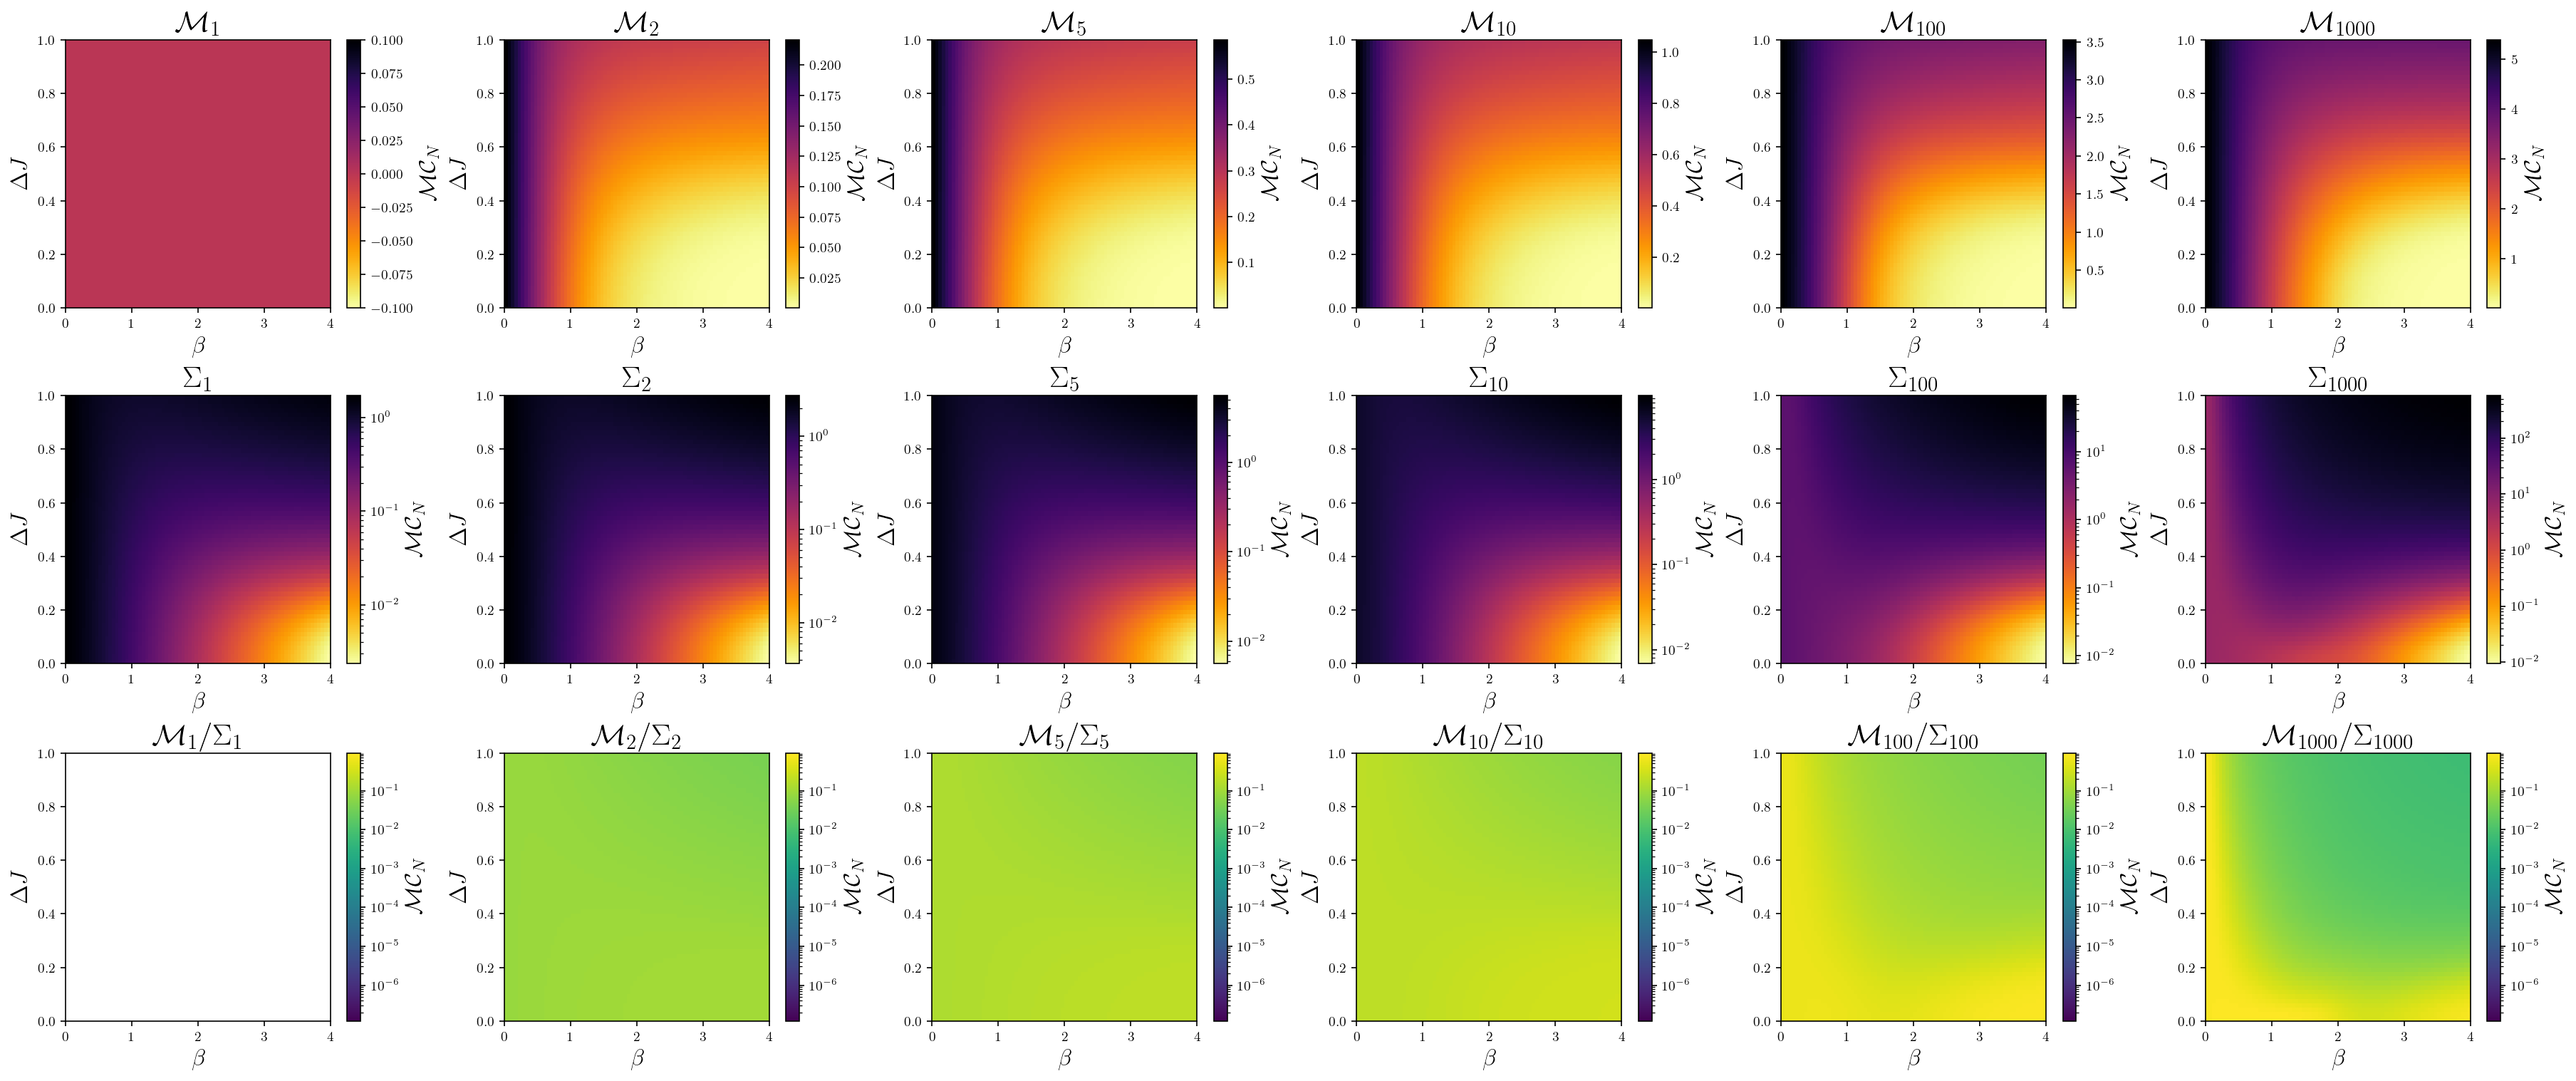

In [94]:

fig, axs = plt.subplots(3, len(N_plot), figsize=(4 * len(N_plot), 10), constrained_layout=True)
# extent = [float(DeltaJ_vals[0]), float(DeltaJ_vals[-1]), float(beta_vals[0]), float(beta_vals[-1])]
extent = [float(beta_vals[0]), float(beta_vals[-1]), float(DeltaJ_vals[0]), float(DeltaJ_vals[-1])]

def add_heatmap(ax: Axes, heatmap, extent, *, cmap='turbo', norm=None):
  return ax.imshow(
    heatmap,
    origin='lower',
    extent=extent,
    aspect='auto',
    cmap=cmap,
    norm=norm
  )



for col, n in enumerate(np.asarray(N_plot, dtype=int)):
  
  im = add_heatmap(axs[0, col], pmmc_cube[:, :, col].T, extent, cmap="inferno_r")
  axs[0, col].set_title(rf"$\mathcal{{M}}_{{{n}}}$")
  # axs[0, col].set(xlabel=r"$\Delta J$", ylabel=r"$\beta$")
  axs[0, col].set(xlabel=r"$\beta$", ylabel=r"$\Delta J$")
  fig.colorbar(im, ax=axs[0, col], label=r"$\mathcal{MC}_N$")

  data = np.asarray(eps_cube[:, :, col].T)
  data = np.ma.masked_less_equal(data, 0.0)
  norm = mcolors.LogNorm(vmin=data.min(), vmax=data.max())
  im = add_heatmap(axs[1, col], eps_cube[:, :, col].T, extent, cmap="inferno_r", norm=norm)
  axs[1, col].set_title(rf"$\Sigma_{{{n}}}$")
  # axs[1, col].set(xlabel=r"$\Delta J$", ylabel=r"$\beta$")
  axs[1, col].set(xlabel=r"$\beta$", ylabel=r"$\Delta J$")
  fig.colorbar(im, ax=axs[1, col], label=r"$\mathcal{MC}_N$")

  data = np.asarray(ratio_cube[:, :, col].T)
  data = np.ma.masked_less_equal(data, 0.0)
  print(ratio_cube.min(), ratio_cube.max())
  norm = mcolors.LogNorm(vmin=ratio_cube.min()+np.finfo(np.float32).eps, vmax=ratio_cube.max())
  im = add_heatmap(axs[2, col], ratio_cube[:, :, col].T, extent, cmap="viridis", norm=norm)
  axs[2, col].set_title(rf"$\mathcal{{M}}_{{{n}}}/\Sigma_{{{n}}}$")
  # axs[2, col].set(xlabel=r"$\Delta J$", ylabel=r"$\beta$")
  axs[2, col].set(xlabel=r"$\beta$", ylabel=r"$\Delta J$")
  fig.colorbar(im, ax=axs[2, col], label=r"$\mathcal{MC}_N$")

In [ ]:
N_max = 200
Ns = jnp.arange(1, N_max + 1)
beta = 4.0
pmmcs_N = np.zeros(N_max, dtype=np.float64)
eps_N = np.zeros(N_max, dtype=np.float64)

for r in range(n_disorder):
  Jij = J0 / N + DeltaJ / np.sqrt(N) * Zs[r]
  np.fill_diagonal(Jij, 0.0)
  fields = sk_fields(jnp.asarray(Jij), spins, Theta)
  pmmcs, eps = sk_pmmc_multiN_fast(p0, rows, spins, fields, beta, gamma, Ns, lam, a_coeff, b_coeff, d_coeff)
  pmmcs_N += np.asarray(pmmcs)
  eps_N += np.asarray(eps)

pmmcs_N = pmmcs_N / n_disorder
eps_N = eps_N / n_disorder 


In [ ]:
# ── SK parameters ─────────────────────────────
J0 = 1.0
DeltaJ = 0.1
beta = 0.5

rng = np.random.default_rng(0)

# one quenched disorder realization
Z = rng.normal(size=(N, N))

# fully asymmetric: DO NOT symmetrize
Jij = J0 / N + DeltaJ / np.sqrt(N) * Z

# standard SK convention / consistent with our flip-rate simplification
np.fill_diagonal(Jij, 0.0)

print("asymmetry =", np.linalg.norm(Jij - Jij.T))

N_max = 2_000
Ns     = jnp.arange(1, N_max + 1)

print("Building K1, K2, heat vectors g1, g2 ...")
fields = sk_fields(jnp.asarray(Jij), spins, Theta)
rates = get_sk_rates(spins, fields, beta, gamma)
K = dense_generator_from_rates(rows, rates)
print("Computing matrix exponentials (once each) ...")
# ── Propagator and time evolution ─────────────
G_dt = expm(K * dt)

# trajectory
pN, pts = get_traj(G_dt, p0, N_max)

Ns = jnp.arange(1, N_max + 1)
p_avgs = jnp.cumsum(pts[:-1], axis=0) / Ns[:, None]
Gp_avgs = p_avgs @ G_dt.T
entropy_diffs = H(pts[1:], axis=1) - H(p0)

# periodic MMC
pmmcs = entropy_diffs + Ns * (H(p_avgs, axis=1) - H(Gp_avgs, axis=1))

# medium entropy
r = medium_entropy_rate_vector(rows, rates)
EM_dt, a_step = precompute_sk_ep(K, r, dt)
ep_curve = entropy_diffs + Ns * (p_avgs @ a_step)


# print("Finding optimal prior q* ...")
# q_phys, residual_step, info = find_optimal_prior(G_dt, c_1step)
# print(f"  converged={info['converged']}, iterations={info['iterations']}, "
#       f"KKT residual={info['kkt_residual']:.2e}, residual EP/step={residual_step:.6f}")
# Gq_phys = G_dt @ q_phys


# ── EP curve — semigroup iteration, no extra expm calls ──────────────────────
# print("Computing EP curve ...")
# EM_n     = np.eye(n_states + 2)
# heats = jnp.zeros(N_max)
# for n in range(N_max):
#   EM_n        = EM_n @ EM_dt
#   A_n         = EM_n[:n_states, n_states:].T              # (2, ns)
#   heats = heats.at[n].add(p0 @ A_n)

# ep_curve = heats + entropy_diffs

# Decomposition: Total EP = MC(q*) + N * residual_step
# so MC(q*) is the "extractable" part of EP relative to the optimal reference.
# mc_steps       = KL(pts[:-1], q_phys, axis=1) - KL(pts[1:], Gq_phys, axis=1)
# mc_phys        = jnp.cumsum(mc_steps)
# residual_curve = Ns * residual_step

# verify decomposition holds
# max_err = np.max(np.abs(ep_curve - mc_phys - residual_curve))
# print(f"  error (should be ~0): {max_err:.2e}")

# ── Stationary state & spectral stuff ──────────────────────────────────────────────────────────
evals, vecs = np.linalg.eig(K)
order = np.argsort(np.abs(evals))#[::-1]
# second largest eigenval -> spectral gap
gap = - evals[order[1]]
# print(evals[order])
t_rel = 1 / gap
print("spectral gap =", gap)
print("relaxation time =", t_rel)

# print(evals[order])
pi  = np.real(vecs[:, order[0]]) # closest to zero
pi  = np.clip(pi / pi.sum(), 0, None)
kl = KL(p0, pi)
nonadiabatic_eps = kl - KL(pts[1:], pi, axis=1)
print(f"pi solved: , D(p0||pi) = {kl}")

q_star = jnp.sum(pts[:-1], axis=0) / N_max
kl = KL(p0, q_star)
print(f"pi known (q_star): , D(p0||pi) = {kl}")




tv_to_pi = 0.5 * jnp.sum(jnp.abs(pts[:-1] - pi[None, :]), axis=1)
eps = 1e-3
indices = np.where(tv_to_pi <= eps)[0]
if len(indices):
  t_mix_p0 = indices[0] * dt
else:
  t_mix_p0 = np.inf

print(f"{t_mix_p0=}, TV at t mix = ")
print(f"{t_mix_p0/dt}")


asymmetry = 0.3856638012807592
Building K1, K2, heat vectors g1, g2 ...
Computing matrix exponentials (once each) ...
spectral gap = (0.5496685412818563-0j)
relaxation time = (1.8192782102245597+0j)
pi solved: , D(p0||pi) = 4.225669200896948
pi known (q_star): , D(p0||pi) = 4.041060192392528
t_mix_p0=np.float64(12.5), TV at t mix = 
125.0


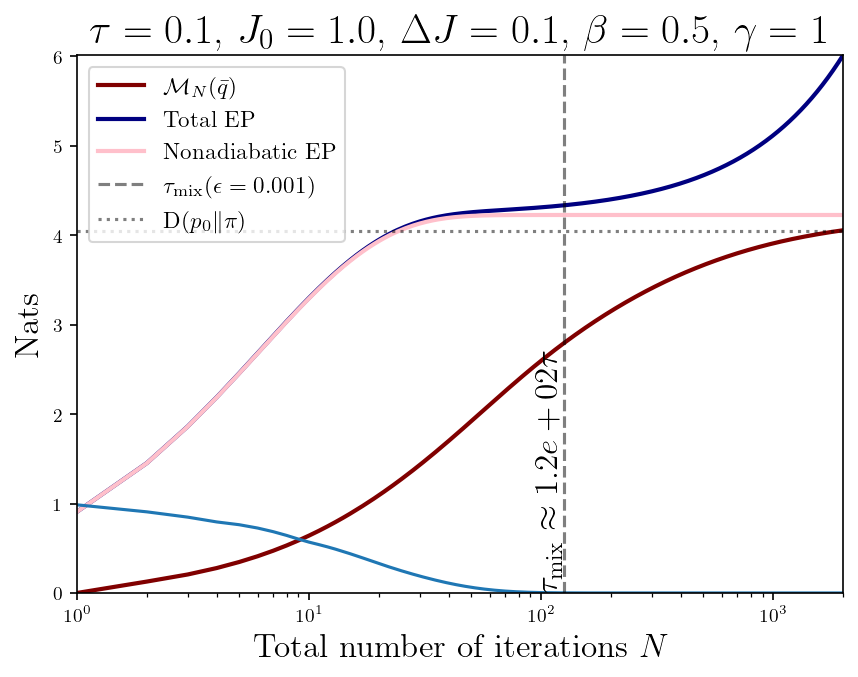

Done.


In [84]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 24/5))
ax.semilogx(Ns, pmmcs,          label=r'$\mathcal{M}_N(\bar{q})$',                    lw=2, color='maroon')
ax.semilogx(Ns, ep_curve,       label=r'Total EP',                             lw=2,   color='navy')
# ax.semilogx(Ns, mc_phys,        label=r'$\mathcal{MC}_N(q)$',                 lw=2,   color='darkgreen')
# ax.semilogx(Ns, residual_curve - other)
# ax.semilogx(Ns, speed_limit, label=r'Speed limit $2\,\mathrm{TV}^2/\mathcal{A}$', lw=1.5, linestyle=':', color='red')
# ax.semilogx(Ns, ep_bound_exact, 'pink')
ax.semilogx(Ns, nonadiabatic_eps, label=r'Nonadiabatic EP', lw=2,  c='pink', alpha=1.0)
ax.semilogx(Ns, tv_to_pi)
# ax.vlines(x=np.round(time), color = 'black', linestyles='dashed', lw=1.5, ymin=0, ymax = ep_curve[-1], label=r'$\tau_{\mathrm{relax}}$', alpha=0.5)
ax.vlines(x=t_mix_p0/dt, color = 'black', linestyles='dashed', lw=1.5, ymin=0, ymax = ep_curve[-1], label=fr'$\tau_{{\mathrm{{mix}}}}(\epsilon={eps})$', alpha=0.5)
ax.text(
  x=t_mix_p0/dt, 
  y=0,                         # 0 places it at the very bottom of the axes
  s=fr"$\tau_{{\mathrm{{mix}}}}\approx {t_mix_p0/dt:.2g}\tau$",                  # Your label text
  transform=ax.get_xaxis_transform(), # Keeps x in data units, y in axes fraction (0 to 1)
  rotation=90,                 # Rotates text to match the vertical line
  verticalalignment='bottom',  # Aligns text boundary
  horizontalalignment='right', # Shifts text slightly so it does not overlap the line
  color='k'
)
ax.hlines(y=kl, xmin=Ns[0], xmax=Ns[-1], color='black', linestyles='dotted', lw=1.5, label=r'$\mathrm{D}(p_0 \| \pi)$', alpha=0.5)
ax.set_title(fr'$\tau={dt}$, $J_0={J0}$, $\Delta J={DeltaJ}$, $\beta={beta:.2g}$, $\gamma={gamma:.2g}$')
ax.legend(fontsize='x-small')
ax.set(xlim=(Ns[0], Ns[-1]), ylim=(0,ep_curve[-1]), xlabel=r'Total number of iterations $N$', ylabel=r'Nats')
plt.tight_layout()
plt.show()
print("Done.")
fig.savefig("glaubner.pdf")


In [ ]:
m_map = np.zeros((n_beta, n_DeltaJ))
ep_ss_map = np.zeros_like(m_map)

for j, DeltaJ in enumerate(DeltaJ_vals):
  m_acc = np.zeros(n_beta)
  ep_acc = np.zeros(n_beta)

  for r_idx in range(n_disorder):
    Jij = Jij_from_disorder(Zs[r_idx], J0, DeltaJ,)
    for i, beta in enumerate(beta_vals):
      m, ep = observables_for_sk(beta, Jij, spins, rows, N, Theta, gamma)
      m_acc[i] += m
      ep_acc[i] += ep

  m_map[:, j] = m_acc / n_disorder
  ep_ss_map[:, j] = ep_acc / n_disorder

In [ ]:
extent = [
    DeltaJ_vals[0],
    DeltaJ_vals[-1],
    beta_vals[0],
    beta_vals[-1],
]

fig, axs = plt.subplots(
    1,
    3,
    figsize=(17, 5),
)

im = axs[0].imshow(
    m_map,
    origin="lower",
    aspect="auto",
    extent=extent,
)

axs[0].set(
    xlabel=r"$\Delta J$",
    ylabel=r"$\beta$",
    title=r"$\langle |m| \rangle$",
)

fig.colorbar(
    im,
    ax=axs[0],
)

im = axs[1].imshow(
    ep_ss_map,
    origin="lower",
    aspect="auto",
    extent=extent,
)

axs[1].set(
    xlabel=r"$\Delta J$",
    ylabel=r"$\beta$",
    title=r"$\dot{\Sigma}_{\rm ss}/N$",
)

fig.colorbar(
    im,
    ax=axs[1],
)

# example MMC at N = 10
im = axs[2].imshow(
    pmmc_cube[:, :, -1],
    origin="lower",
    aspect="auto",
    extent=extent,
)

axs[2].set(
    xlabel=r"$\Delta J$",
    ylabel=r"$\beta$",
    title=fr"$\mathcal{{MC}}_{{{N_max}}}$",
)

fig.colorbar(
    im,
    ax=axs[2],
)

plt.tight_layout()

In [ ]:
from numpy.polynomial.hermite import hermgauss

xgh, wgh = hermgauss(80)

zgh = np.sqrt(2.0) * xgh
wgh = wgh / np.sqrt(np.pi)


def gaussian_expectation(f):
  return np.sum(wgh * f(zgh))


def solve_m(beta, DeltaJ, J0=1.0, tol=1e-12, maxiter=10000):
  # start positive to select the
  # positive broken-symmetry branch
  m = 1.0

  for _ in range(maxiter):
    m_new = gaussian_expectation(lambda z: np.tanh(beta * (J0 * m + DeltaJ * z)))
    if abs(m_new - m) < tol:
      return m_new

    m = 0.5 * m + 0.5 * m_new

  return m

Critical line at Eq. (59):
$$
\frac{1}{\beta J_0} = \int Dz \mathrm{sech}^2(\beta\Delta J z).
$$

In [ ]:
from scipy.optimize import brentq

def critical_DeltaJ(beta, J0=1.0, upper=2.0):
  if beta * J0 <= 1.0:
    return np.nan

  target = 1.0 / (beta * J0)

  def f(DeltaJ):
    rhs = gaussian_expectation(lambda z: 1.0 / np.cosh(beta * DeltaJ * z)**2)
    return rhs - target

  return brentq(f, 0.0, upper)

In [ ]:
critical = np.array([
    critical_DeltaJ(beta, J0)
    for beta in beta_vals
])

for ax in axs:
    mask = np.isfinite(critical)

    ax.plot(
        critical[mask],
        beta_vals[mask],
        "w--",
        lw=2,
    )